125


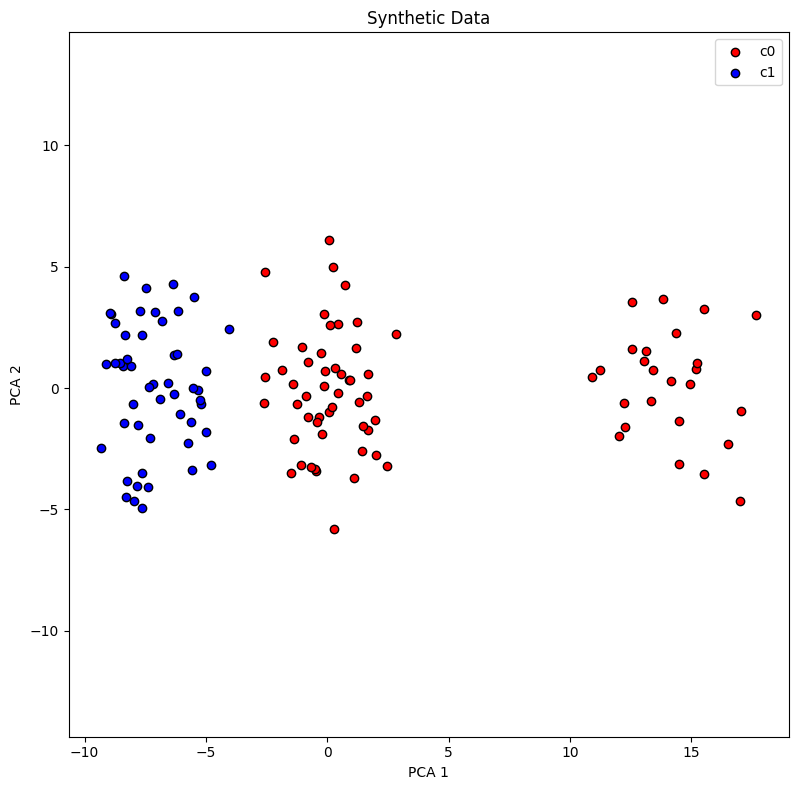

(75, 50)
(50, 50)
()
combined-data
[[ 2.18478598  2.56837199  1.57552681 ...  0.64772912  2.25505401
   1.82325289]
 [ 0.09365494  1.06023039 -0.47561787 ...  0.08469868 -0.55988673
   1.03030633]
 [-0.22840925  1.08213307 -1.08678789 ...  0.66697901  3.63427213
   1.30665676]
 ...
 [ 2.92359239  0.39244506 -0.3869232  ...  1.79670446 -0.32927588
  -0.05867413]
 [-1.70762724  1.95195829 -1.48716694 ... -0.22134363  1.50625339
  -2.8246862 ]
 [ 0.98862885  1.54476108 -0.13733065 ...  0.84048103  0.16577862
  -1.77543477]]
(125, 50)
normalised
The graph is composed of 1 connected component(s).


Starting computation for t=10.0 and k=10 and knn=10
Starting computation for t=10.0 and k=10
Chebyshev coefficients:
[ 3.18017482e-01 -2.92670005e-01  2.28820696e-01 -1.53195032e-01
  8.87533412e-02 -4.49979135e-02  2.01834641e-02 -8.09013136e-03
  2.92410744e-03 -9.60709671e-04  2.88955491e-04]
m_0 (balanced)
[0.01333333 0.01333333 0.01333333 0.01333333 0.01333333 0.01333333
 0.01333333 0.013333

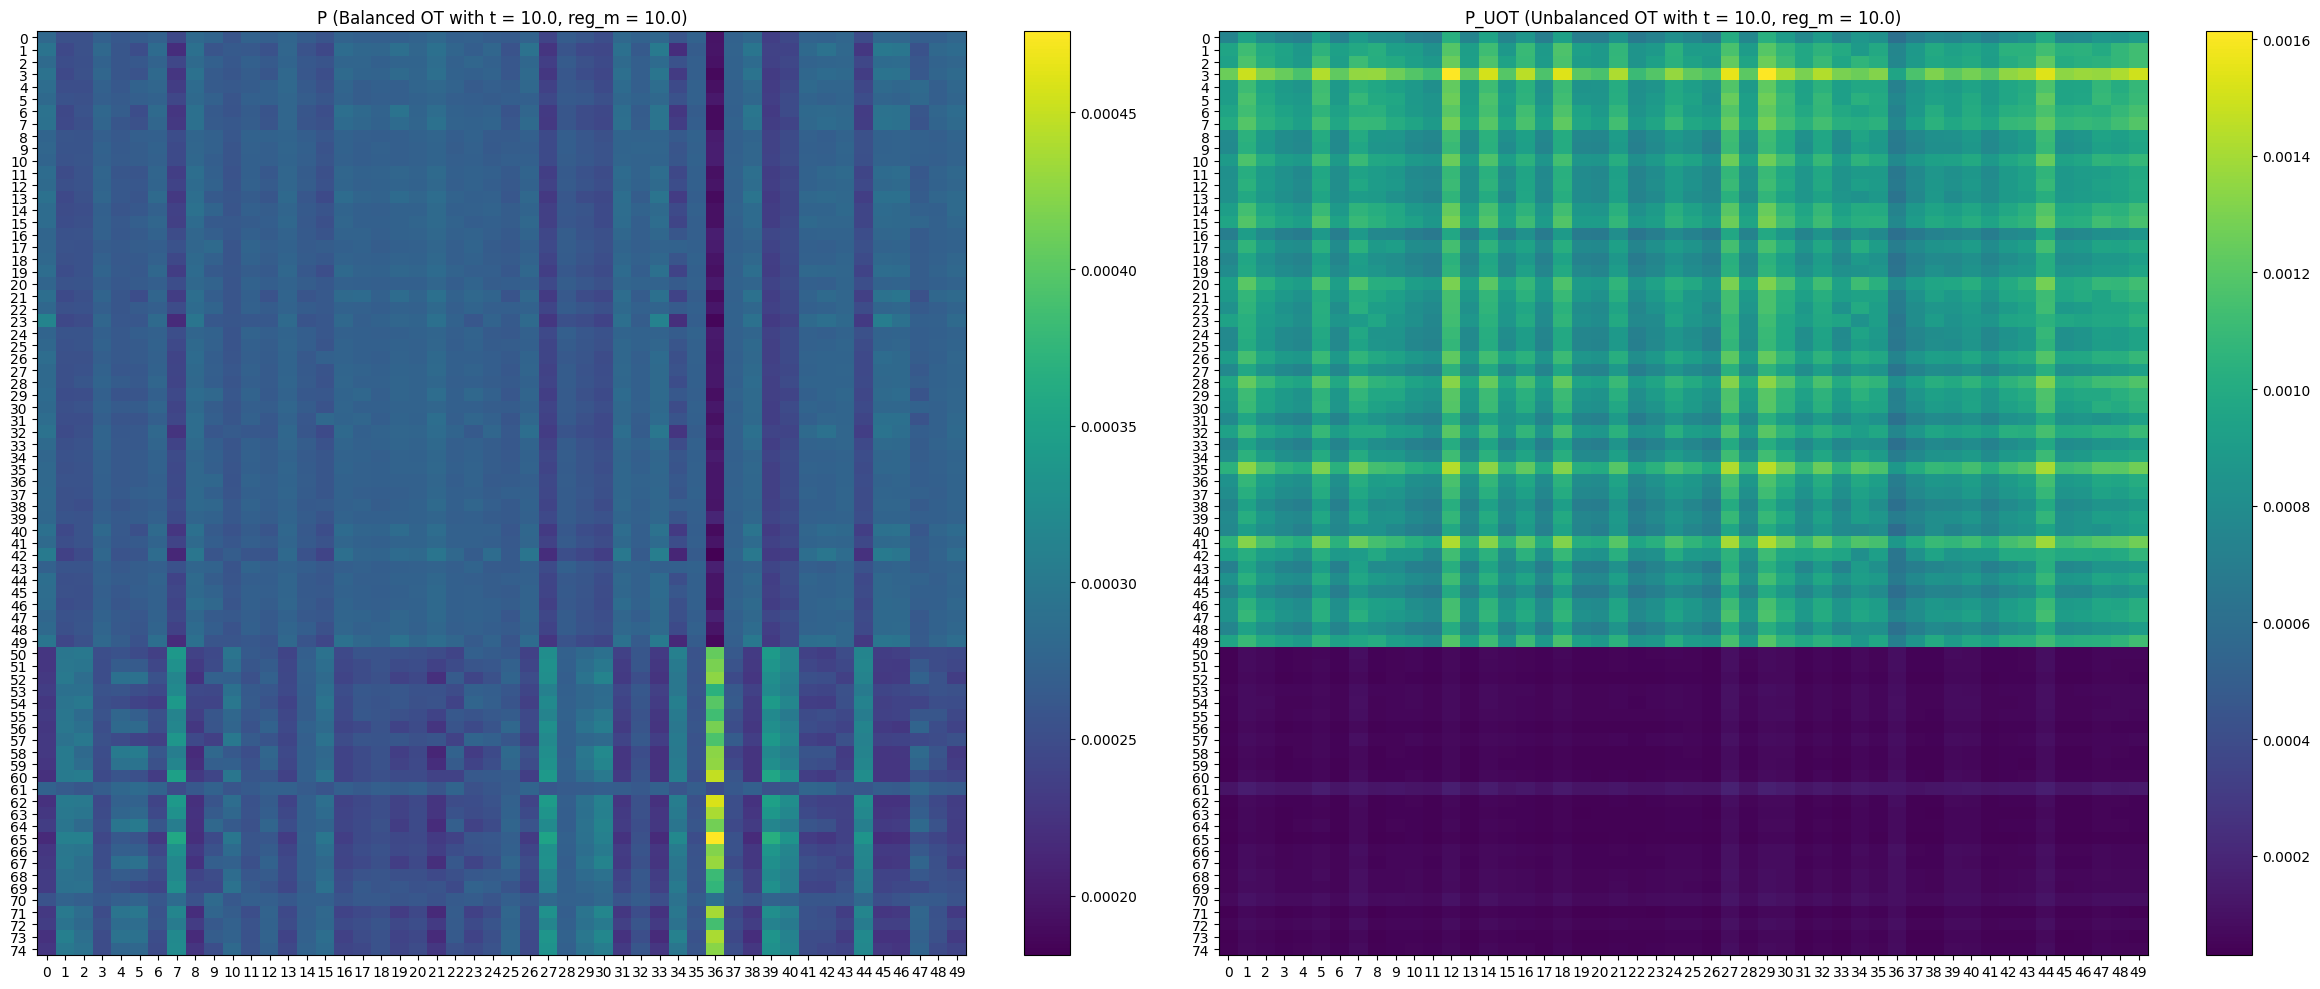

/var/folders/b6/zj_lgsyj5f3fyp934xb5ck_00000gn/T/ipykernel_69855/1006253177.py:311: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar


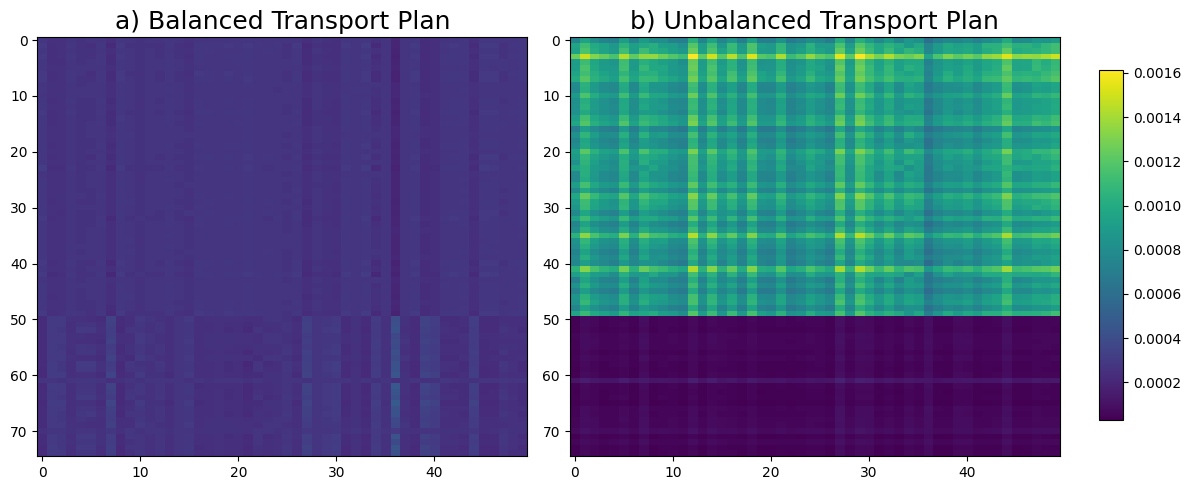

/var/folders/b6/zj_lgsyj5f3fyp934xb5ck_00000gn/T/ipykernel_69855/1006253177.py:335: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


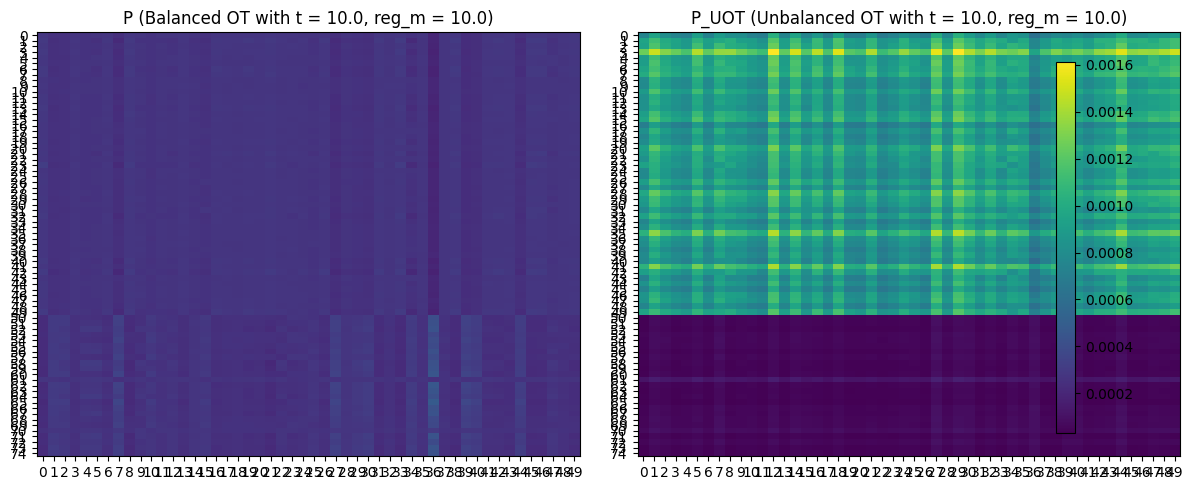

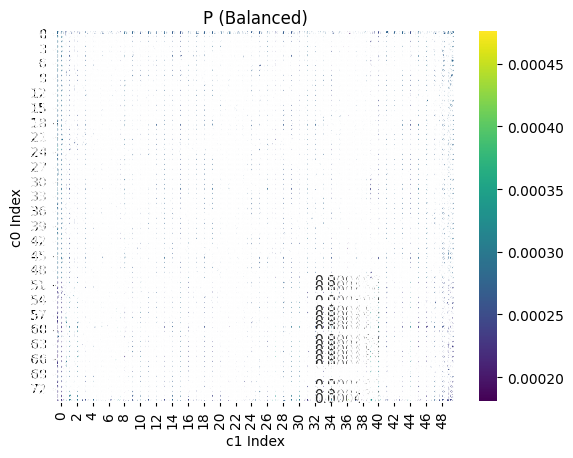

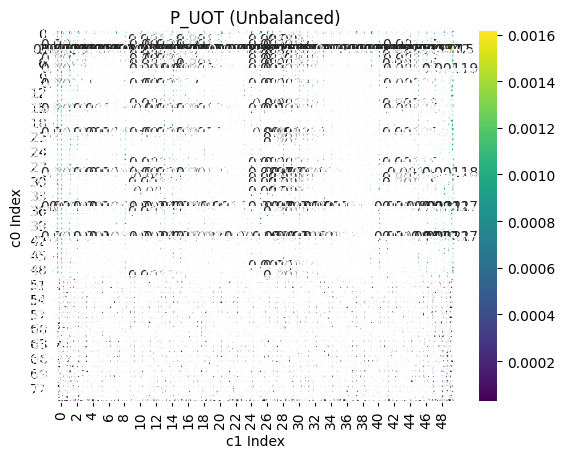

/var/folders/b6/zj_lgsyj5f3fyp934xb5ck_00000gn/T/ipykernel_69855/1006253177.py:372: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


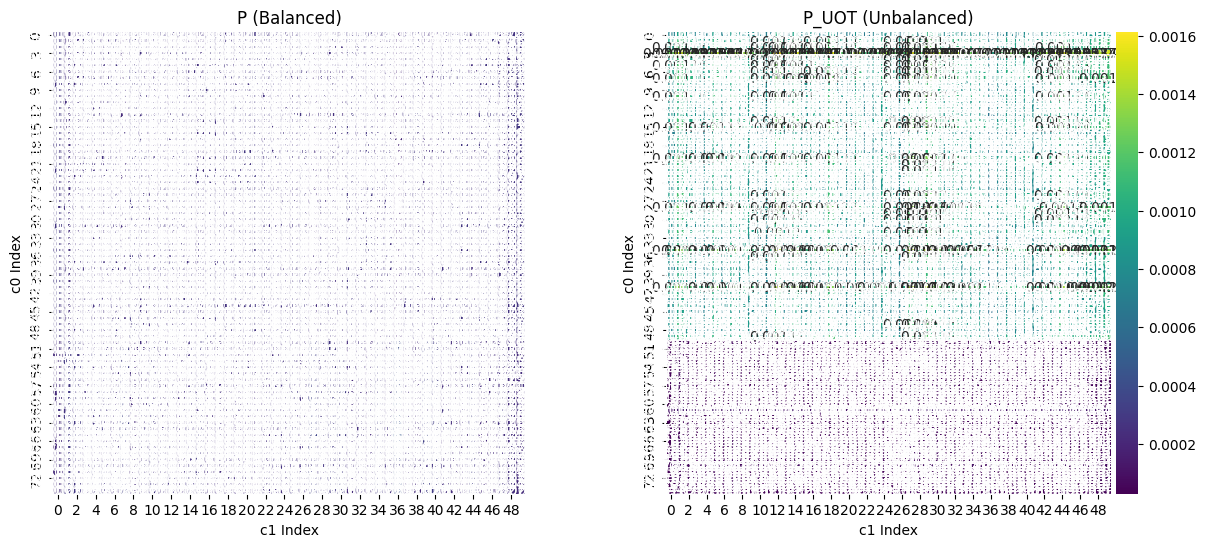

Mean P
Mean P_UOT
0.560355888090636
0.39486130130218516


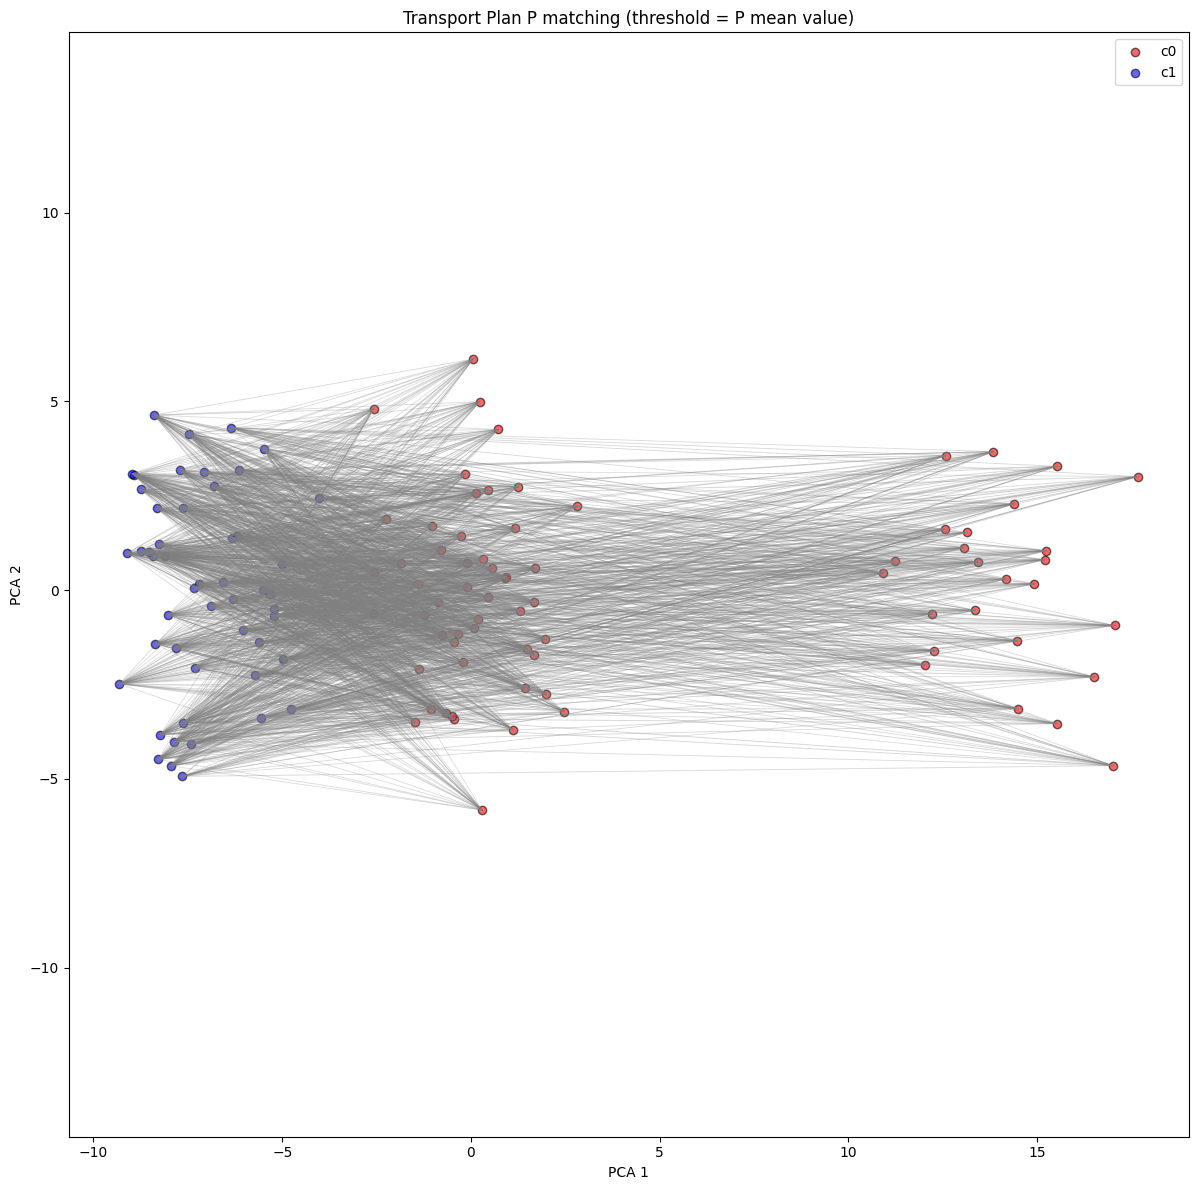

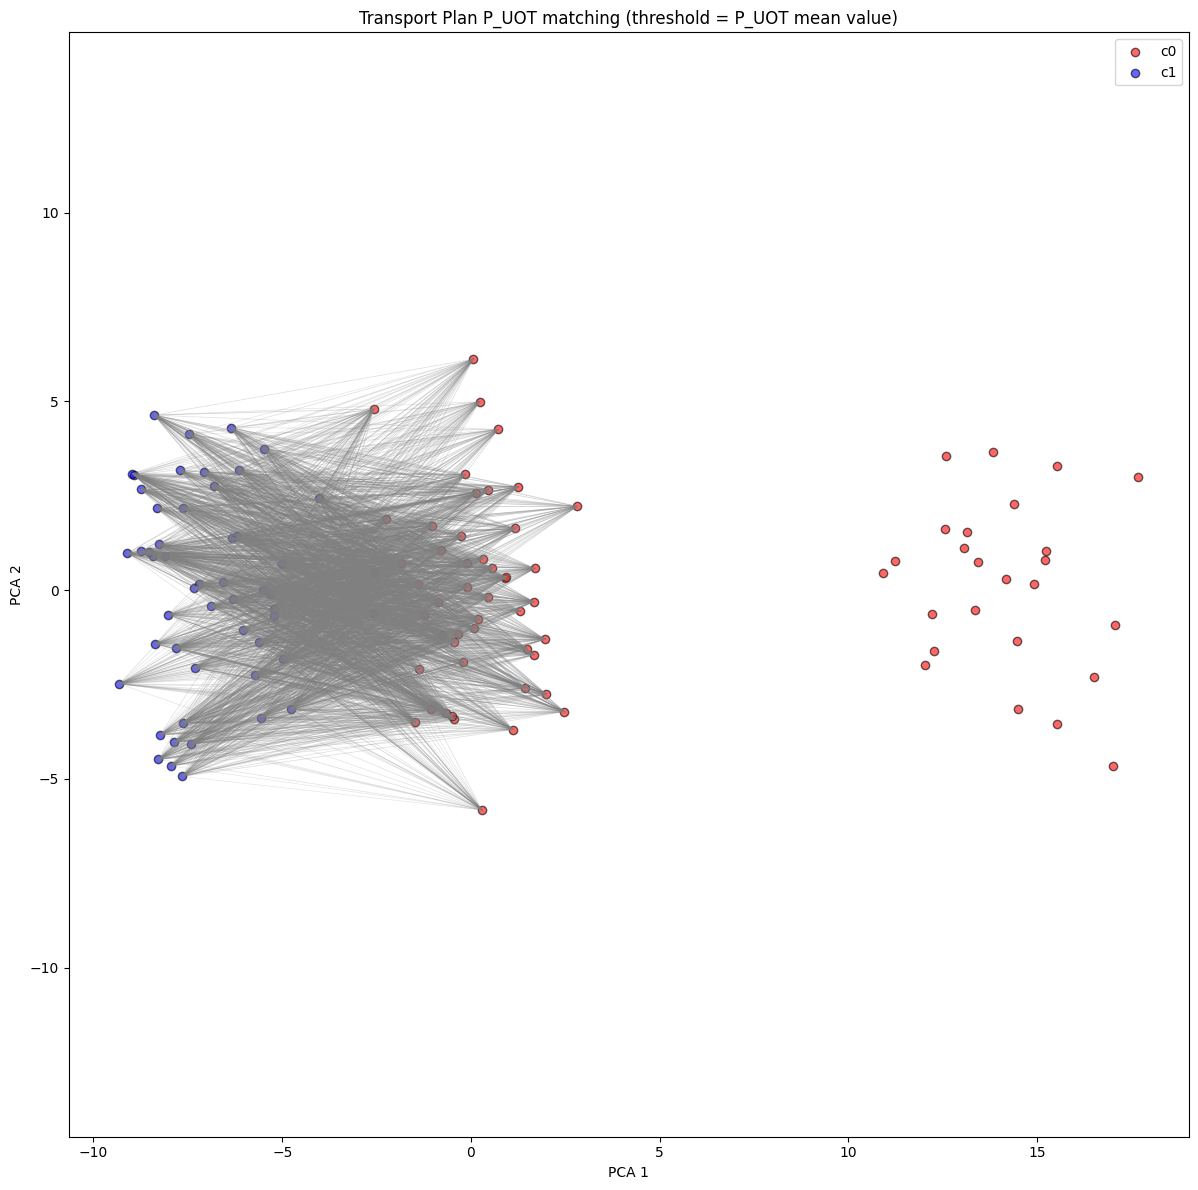

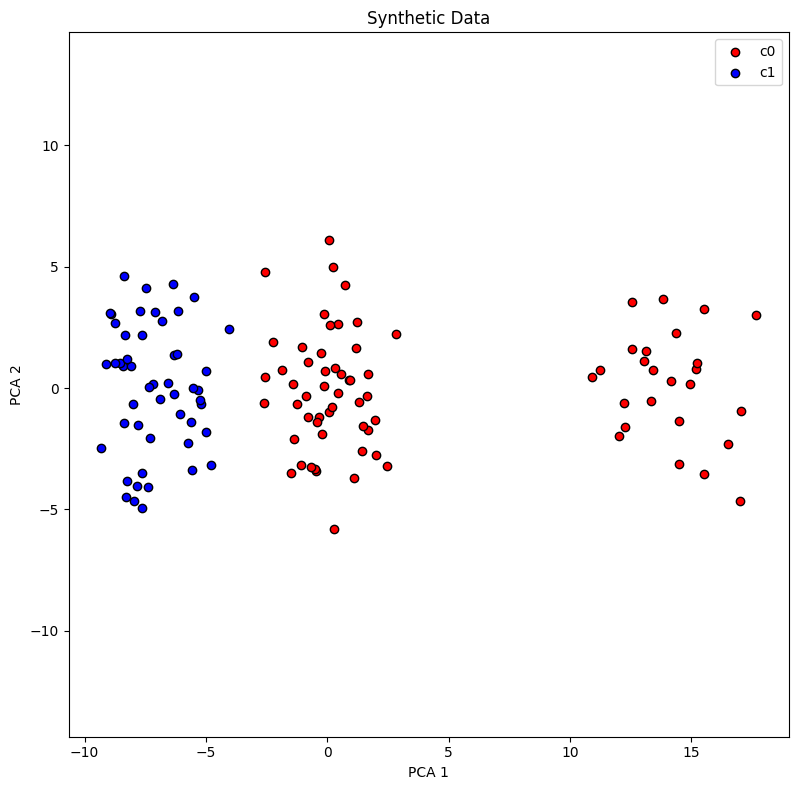

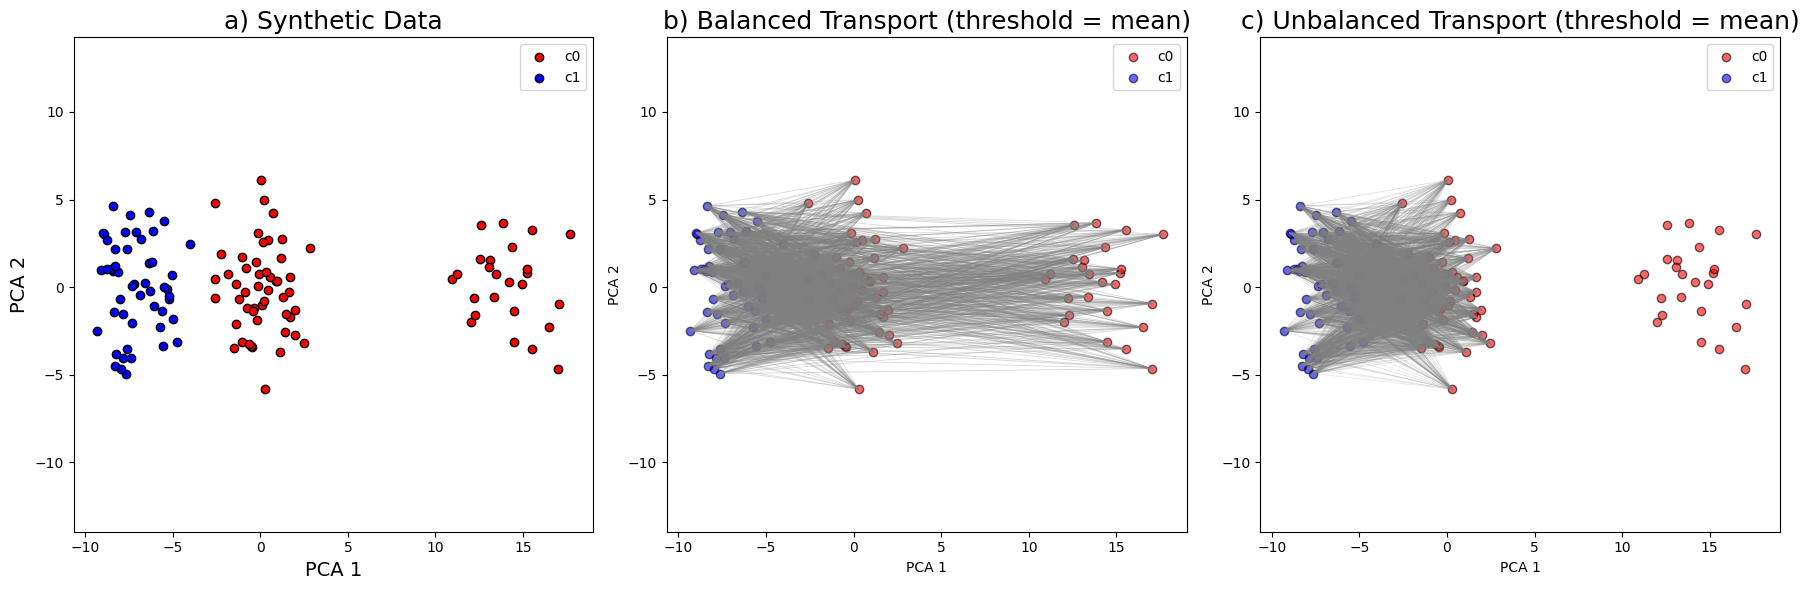

In [ ]:
import time
import signal
import sys
import convolutional_sinkhorn
import UOT_convolutional_sinkhorn
import matplotlib.pyplot as plt 
import numpy as np
import time
import phate
from scipy.sparse.linalg import eigsh 
from scipy.special import ive  
import graphtools
from scipy.sparse.linalg import eigsh 
from scipy.sparse.csgraph import connected_components
from sklearn.decomposition import PCA
import seaborn as sns
from scipy.optimize import linear_sum_assignment

start_time = time.time()
RESULT_FILE = '/Users/x/Documents/AD015/condition_matrix_1st_rep.csv'


import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_pca(*c_arrays):
    """
    Perform PCA on an arbitrary number of arrays and plot the results.
    
    Parameters:
    *c_arrays: Variable number of numpy arrays to analyze
    """
    # Stack all arrays vertically
    all_data = np.vstack(c_arrays)
    
    
    labels = []
    for i, arr in enumerate(c_arrays):
        labels.extend([i] * len(arr))


    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(all_data)

    plt.figure(figsize=(8, 8))
    colors = ['red', 'blue']

    for i, color in enumerate(colors):
        idx = np.array(labels) == i
        plt.scatter(pca_result[idx, 0], pca_result[idx, 1], 
                label=f'c{i}', alpha=1.0, color=color, edgecolor='k')

    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.title(f'Synthetic Data')
    plt.legend()
    plt.tight_layout() 
    plt.axis('equal')
    plt.show()
        

def save_results_and_exit(signum, frame):
    print(f"\nReceived termination signal {signum}. Saving results and exiting...")
    np.savetxt(RESULT_FILE, condition_matrix, delimiter=',', header='m_0', comments='')
    sys.exit(0)  # Ensure graceful exit


signal.signal(signal.SIGTERM, save_results_and_exit)  # Catches SGE job termination
signal.signal(signal.SIGUSR1, save_results_and_exit)  # Optional custom signal


def compute_chebychev_coeff_all(phi, tau, K):
    return 2 * ive(np.arange(0, K + 1), -tau * phi)


def generate_gaussian_points(data, n_points, mean=0, std=0.5):
    gaussian_points = []
    for point in data:
        gaussian_points.append(np.random.normal(loc=point, scale=std, size=(n_points, len(point))))
    return np.array(gaussian_points)


def synthetic_data_generation(points,features,x0,xn, d0, dn, random_state=42):
    rng = np.random.default_rng(random_state)
    n = np.random.uniform(x0, xn)
    m = np.random.uniform(d0,dn)
    generated_data = np.random.normal(n,m,(points,features))
    return generated_data



def main():
    global condition_matrix  

    try:
        
        condition_sizes = [75,50]
        total_num_cells = np.sum(condition_sizes)
        print(total_num_cells)
        N = 2
        num_features = 50 # Number of features per cell  
        conditions =[]
        
        c0 = synthetic_data_generation(50, num_features, 1.0, 1.0, 1.5, 1.5) 
        c1 = synthetic_data_generation(50, num_features, 0, 0, 1.5,1.5)
        outliers = synthetic_data_generation(25, num_features,3.0, 3.0, 1.5,1.5)
  
        c0 = np.vstack([c0, outliers])
        conditions.append(c0)
        conditions.append(c1)  
  
        
             
        plot_pca(c0, c1)
        
        print(np.shape(c0))
        print(np.shape(c1))
        
        K = 0
        print(np.shape(K))

            
        
        cs = np.vstack(conditions)
        
        print('combined-data')
        print(cs)
        print(np.shape(cs)) 

        
        t_list = [10.0]
        k_list = [10]
        knn_list = [10]
        reg_m_list = [10.0]
    
          
        for knn in knn_list:

            graph = graphtools.Graph(cs , use_pygsp=True, knn=knn)
            graph.compute_laplacian("normalized")  # Compute normalized Laplacian
            print('normalised')
            L = graph.L

            n_components, labels = connected_components(csgraph=L, directed=False, connection='weak')
            print(f"The graph is composed of {n_components} connected component(s).")

            for k in k_list:
                for t in t_list:
                    for reg_m in reg_m_list:

                  
                        print(f"\n\nStarting computation for t={t} and k={k} and knn={knn}")
                        condition_matrix_balanced = np.zeros((N,N))
                        condition_matrix_unbalanced = np.zeros((N,N))
                        
                        print(f"Starting computation for t={t} and k={k}")

                        phi = eigsh(L, k=k, return_eigenvectors=False)[0] / 2  # Compute the largest eigenvalue divided by 2
                        coeff = compute_chebychev_coeff_all(phi, t, k)  # Compute Chebyshev coefficients
                        print("Chebyshev coefficients:")
                        print(coeff)

                        for A, _ in enumerate(conditions):
                            for B, _ in enumerate(conditions): 
                                if B > A:
                                    start_A = sum(condition_sizes[:A])
                                    end_A = start_A + condition_sizes[A] - 1
                                    start_B = sum(condition_sizes[:B])
                                    end_B = start_B + condition_sizes[B] - 1

                                    m_0 = np.zeros(total_num_cells,)
                                    m_0[start_A:end_A+1] = 1
                                    m_0 = m_0 / np.sum(m_0) 
                                    print('m_0 (balanced)')
                                    print(m_0)
                                    m_1 = np.zeros(total_num_cells,)
                                    m_1[start_B:end_B+1] = 1
                                    m_1 = m_1 / np.sum(m_1)
                                    print('m_1 (balanced)')
                                    print(m_1)
                                    
                                    N = len(m_0)
                                    a = np.ones(N) / N
                                    dist_w, P = convolutional_sinkhorn.fastcheb_conv_sinkhorn(L, m_0, m_1, phi, coeff, t=t, k=k, verbose = True,  P=K)
                                    print ('Balanced OT: dist_w for condition',A, 'and condition', B,' = ', dist_w)
                            
                    
                                    
                                    P_cropped = P[:condition_sizes[0],condition_sizes[0]:]
                                    
                                    condition_matrix_balanced[A, B] = dist_w
                                    condition_matrix_balanced[B, A] = dist_w
                                    
                                    start_A_UOT = sum(condition_sizes[:A])
                                    end_A_UOT = start_A_UOT + condition_sizes[A] - 1
                                    start_B_UOT = sum(condition_sizes[:B])
                                    end_B_UOT = start_B_UOT + condition_sizes[B] - 1

                                    m_0_UOT = np.zeros(total_num_cells,)
                                    m_0_UOT[start_A_UOT:end_A_UOT+1] = 1
                            
                                    print('m_0_UOT (unbalanced)')
                                    print(m_0_UOT)
                                    
                                    m_1_UOT = np.zeros(total_num_cells,)
                                    m_1_UOT[start_B_UOT:end_B_UOT+1] = 1
                                    print('m_1 (unbalanced)')
                                    print(m_1_UOT)

                                    dist_w_UOT, P_UOT = UOT_convolutional_sinkhorn.fastcheb_conv_sinkhorn(L, m_0_UOT, m_1_UOT, phi, coeff,reg_m, t=t, k=k, verbose = True, P=K)
                                    print ('Unbalanced OT: dist_w for condition',A, 'and condition', B,' = ', dist_w)
                        
                    
                                    P_UOT_cropped = P_UOT[:condition_sizes[0],condition_sizes[0]:]
                                
                                    condition_matrix_unbalanced[A, B] = dist_w_UOT
                                    condition_matrix_unbalanced[B, A] = dist_w_UOT
                        
                                
                                    P_norm = P * a
                                    P_UOT_norm = P_UOT * a
                                    
                                    P_norm_cropped = P_norm[:condition_sizes[0],condition_sizes[0]:]
                                    P_UOT_norm_cropped = P_UOT_norm[:condition_sizes[0],condition_sizes[0]:]
                        
                                        
                                    # Plot P and P_UOT as heatmaps
                                    fig, axes = plt.subplots(1, 2, figsize=(24, 10))
                                    im_p = axes[0].imshow(P_norm_cropped, cmap='viridis', aspect='auto')
                                    axes[0].set_title(f'P (Balanced OT with t = {t}, reg_m = {reg_m})')
                                    plt.colorbar(im_p, ax=axes[0])

                                    # Plot unbalanced OT
                                    im_pu = axes[1].imshow(P_UOT_norm_cropped, cmap='viridis', aspect='auto')
                                    axes[1].set_title(f'P_UOT (Unbalanced OT with t = {t}, reg_m = {reg_m})')
                                    plt.colorbar(im_pu, ax=axes[1])
                                    

                                    # Set ticks for both subplots
                                    for ax in axes:
                                        ax.set_xticks(np.arange(0, P_cropped.shape[1], 1))
                                        ax.set_yticks(np.arange(0, P_cropped.shape[0], 1))

                                    plt.tight_layout()
                                    plt.show()
                                    
                                  
                                    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

                                    vmin = min(np.min(P_norm_cropped), np.min(P_UOT_norm_cropped))
                                    vmax = max(np.max(P_norm_cropped), np.max(P_UOT_norm_cropped))

                                    im_p = axes[0].imshow(P_norm_cropped, cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
                                    axes[0].set_title(f'a) Balanced Transport Plan', fontsize= 18)

                                    im_pu = axes[1].imshow(P_UOT_norm_cropped, cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
                                    axes[1].set_title(f'b) Unbalanced Transport Plan', fontsize= 18)

                              
                                    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
                                    fig.colorbar(im_p, cax=cbar_ax) 

                                    plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar
                                    plt.savefig(f'/Users/x/Documents/POT_unbalanced/UOT_OT_transport_plans.png', dpi=750, bbox_inches='tight')
                                    plt.show()

                                    
                                    fig, axes = plt.subplots(1, 2, figsize=(12, 5))


                                    vmin = min(np.min(P_norm_cropped), np.min(P_UOT_norm_cropped))
                                    vmax = max(np.max(P_norm_cropped), np.max(P_UOT_norm_cropped))

                                    im_p = axes[0].imshow(P_norm_cropped, cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
                                    axes[0].set_title(f'P (Balanced OT with t = {t}, reg_m = {reg_m})')

                                    im_pu = axes[1].imshow(P_UOT_norm_cropped, cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
                                    axes[1].set_title(f'P_UOT (Unbalanced OT with t = {t}, reg_m = {reg_m})')

                                    for ax in axes:
                                        ax.set_xticks(np.arange(0, P_cropped.shape[1], 1))
                                        ax.set_yticks(np.arange(0, P_cropped.shape[0], 1))
 
                                    fig.colorbar(im_p, ax=axes, orientation='vertical', fraction=0.02, pad=0.10, location='right')
                                    

                                    plt.tight_layout()
                                  
                                    plt.show()
                                    
                                    
                                    sns.heatmap(P_norm_cropped, annot=True, cmap='viridis', fmt='.3g')
                                    plt.title('P (Balanced)')
                                    plt.xlabel('c1 Index')
                                    plt.ylabel('c0 Index')
                             
                                    plt.show()
                                    
                                    sns.heatmap(P_UOT_norm_cropped, annot=True, cmap='viridis', fmt='.3g')
                                    plt.title('P_UOT (Unbalanced)')
                                    plt.xlabel('c1 Index')
                                    plt.ylabel('c0 Index')
 
                                    plt.show()
                                    
                                    fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.3})
                                    from mpl_toolkits.axes_grid1 import make_axes_locatable
                                    divider = make_axes_locatable(axes[1])
                                    cax = divider.append_axes("right", size="5%", pad=0.05)

                                    vmin = min(np.min(P_norm_cropped), np.min(P_UOT_norm_cropped))
                                    vmax = max(np.max(P_norm_cropped), np.max(P_UOT_norm_cropped))

                                    sns.heatmap(P_norm_cropped, annot=True, cmap='viridis', fmt='.3g', ax=axes[0], cbar=False, vmin=vmin, vmax=vmax)
                                    axes[0].set_title('P (Balanced)')
                                    axes[0].set_xlabel('c1 Index')
                                    axes[0].set_ylabel('c0 Index')

                                    sns.heatmap(P_UOT_norm_cropped, annot=True, cmap='viridis', fmt='.3g', ax=axes[1], cbar=True, cbar_ax=cax, vmin=vmin, vmax=vmax)
                                    axes[1].set_title('P_UOT (Unbalanced)')
                                    axes[1].set_xlabel('c1 Index')
                                    axes[1].set_ylabel('c0 Index')

                                    plt.tight_layout()
                                    plt.show()
                            
                                    P_norm_cropped =  P_norm_cropped/np.max(P_norm_cropped)
                                    P_UOT_norm_cropped =  P_UOT_norm_cropped/np.max(P_UOT_norm_cropped)
                                    P_mean = np.mean(P_norm_cropped)
                                    P_UOT_mean = np.mean(P_UOT_norm_cropped)
                                    
                                    print('Mean P')
                                    print('Mean P_UOT')
                                    print(P_mean)
                                    print(P_UOT_mean)
                                    
                                    all_data = np.vstack([c0, c1])
                                    pca = PCA(n_components=2)
                                    pca_result = pca.fit_transform(all_data)
                                    c0_pca = pca_result[:len(c0)]
                                    c1_pca = pca_result[len(c0):]

                            

                                    plt.figure(figsize=(12, 12))
                                    for i in range(P_norm_cropped.shape[0]):
                                        for j in range(P_norm_cropped.shape[1]):
                                            strength = P_norm_cropped[i, j]
                                            if strength > P_mean:
                                                x0, y0 = c0_pca[i, 0], c0_pca[i, 1]
                                                x1, y1 = c1_pca[j, 0], c1_pca[j, 1]
                                                plt.plot([x0, x1], [y0, y1], color='gray', alpha=0.5*strength, linewidth=strength)
                                    plt.scatter(c0_pca[:, 0], c0_pca[:, 1], label='c0', alpha=0.6, edgecolor='k', color='red')
                                    plt.scatter(c1_pca[:, 0], c1_pca[:, 1], label='c1', alpha=0.6, edgecolor='k', color='blue')
                                    plt.xlabel('PCA 1')
                                    plt.ylabel('PCA 2')
                                    plt.title('Transport Plan P matching (threshold = P mean value)')
                                    plt.legend()
                                    plt.tight_layout()
                                    plt.axis('equal')
                                    plt.show()

                                    plt.figure(figsize=(12, 12))
                                    plt.scatter(c0_pca[:, 0], c0_pca[:, 1], label='c0', alpha=0.6, edgecolor='k', color='red')
                                    plt.scatter(c1_pca[:, 0], c1_pca[:, 1], label='c1', alpha=0.6, edgecolor='k', color='blue')
                                    for i in range(P_norm_cropped.shape[0]):
                                        for j in range(P_UOT_norm_cropped.shape[1]):
                                            strength = P_UOT_norm_cropped[i, j]
                                            if strength > P_UOT_mean:
                                                x0, y0 = c0_pca[i, 0], c0_pca[i, 1]
                                                x1, y1 = c1_pca[j, 0], c1_pca[j, 1]
                                                plt.plot([x0, x1], [y0, y1], color='gray', alpha=0.5*strength, linewidth=strength)
                                    plt.xlabel('PCA 1')
                                    plt.ylabel('PCA 2')
                                    plt.title('Transport Plan P_UOT matching (threshold = P_UOT mean value)')
                                    plt.legend()
                                    plt.tight_layout()
                                    plt.axis('equal')
                                    plt.show()
                                    
                                
                                    all_data = np.vstack([c0, c1])
    
    
                                    labels = []
                                    for i, arr in enumerate([c0, c1]):
                                        labels.extend([i] * len(arr))


                                    pca = PCA(n_components=2)
                                    pca_result = pca.fit_transform(all_data)

                                    plt.figure(figsize=(8, 8))
                                    colors = ['red', 'blue']

                                    for i, color in enumerate(colors):
                                        idx = np.array(labels) == i
                                        plt.scatter(pca_result[idx, 0], pca_result[idx, 1], 
                                                label=f'c{i}', alpha=1.0, color=color, edgecolor='k')

                                    plt.xlabel('PCA 1')
                                    plt.ylabel('PCA 2')
                                    plt.title(f'Synthetic Data')
                                    plt.legend()
                                    plt.tight_layout() 
                                    plt.axis('equal')
                                    plt.savefig(f'/Users/x/Documents/POT_unbalanced/transport_plans.png', dpi=750, bbox_inches='tight')
                                    plt.show()
                                    
                      

                                    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
                                    
                                    # 3. Synthetic Data PCA scatter
                                    colors = ['red', 'blue']
                                    labels = []
                                    for i, arr in enumerate([c0, c1]):
                                        labels.extend([i] * len(arr))
                                    for i, color in enumerate(colors):
                                        idx = np.array(labels) == i
                                        axes[0].scatter(pca_result[idx, 0], pca_result[idx, 1], 
                                                        label=f'c{i}', alpha=1.0, color=color, edgecolor='k')
                                    axes[0].set_xlabel('PCA 1', fontsize = 14)
                                    axes[0].set_ylabel('PCA 2', fontsize = 14)
                                    axes[0].set_title('a) Synthetic Data', fontsize = 18)
                                    axes[0].legend()
                                    axes[0].axis('equal')

                                  

                           
                                    for i in range(P_norm_cropped.shape[0]):
                                        for j in range(P_norm_cropped.shape[1]):
                                            strength = P_norm_cropped[i, j]
                                            if strength > P_mean:
                                                x0, y0 = c0_pca[i, 0], c0_pca[i, 1]
                                                x1, y1 = c1_pca[j, 0], c1_pca[j, 1]
                                                axes[1].plot([x0, x1], [y0, y1], color='gray', alpha=0.5*strength, linewidth=strength)
                                    axes[1].scatter(c0_pca[:, 0], c0_pca[:, 1], label='c0', alpha=0.6, edgecolor='k', color='red')
                                    axes[1].scatter(c1_pca[:, 0], c1_pca[:, 1], label='c1', alpha=0.6, edgecolor='k', color='blue')
                                    axes[1].set_xlabel('PCA 1')
                                    axes[1].set_ylabel('PCA 2')
                                    axes[1].set_title('b) Balanced Transport (threshold = mean)' , fontsize = 18)
                                    axes[1].legend()
                                    axes[1].axis('equal')

                              
                                    axes[2].scatter(c0_pca[:, 0], c0_pca[:, 1], label='c0', alpha=0.6, edgecolor='k', color='red')
                                    axes[2].scatter(c1_pca[:, 0], c1_pca[:, 1], label='c1', alpha=0.6, edgecolor='k', color='blue')
                                    for i in range(P_norm_cropped.shape[0]):
                                        for j in range(P_UOT_norm_cropped.shape[1]):
                                            strength = P_UOT_norm_cropped[i, j]
                                            if strength > P_UOT_mean:
                                                x0, y0 = c0_pca[i, 0], c0_pca[i, 1]
                                                x1, y1 = c1_pca[j, 0], c1_pca[j, 1]
                                                axes[2].plot([x0, x1], [y0, y1], color='gray', alpha=0.5*strength, linewidth=strength)
                                    axes[2].set_xlabel('PCA 1')
                                    axes[2].set_ylabel('PCA 2')
                                    axes[2].set_title('c) Unbalanced Transport (threshold = mean)', fontsize = 18)
                                    axes[2].legend()
                                    axes[2].axis('equal')
                                    plt.tight_layout()
                                    plt.savefig(f'/Users/x/Documents/POT_unbalanced/transport_between_distributions.png', dpi=750, bbox_inches='tight')
                                    plt.show()                         
                                    
         
    except KeyboardInterrupt:
        print("\nJob interrupted manually (CTRL+C). Saving results...")
        np.savetxt(RESULT_FILE, condition_matrix, delimiter=',', comments='')


if __name__ == '__main__':
    main()